In [1]:
import sys
import os
sys.path.append(os.path.abspath('../'))
import pandas as pd
import numpy as np
import joblib
import shap
from src.explainability import plot_builtin_importance, perform_shap_analysis, plot_individual_explanation

/Users/mac/Documents/kaim/fraud-detection/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_test_raw = pd.read_csv('../data/processed/X_test_final.csv')
y_test = pd.read_csv('../data/processed/y_test_final.csv').values.ravel()
best_rf = joblib.load('../models/random_forest_model.pkl')

In [3]:
features = best_rf.feature_names_in_
X_test = X_test_raw[features]

print(f"Model loaded and data aligned. Feature count: {len(features)}")

Model loaded and data aligned. Feature count: 14


/Users/mac/Documents/kaim/fraud-detection/src/explainability.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.head(top_n).values, y=feat_imp.head(top_n).index, palette='viridis')


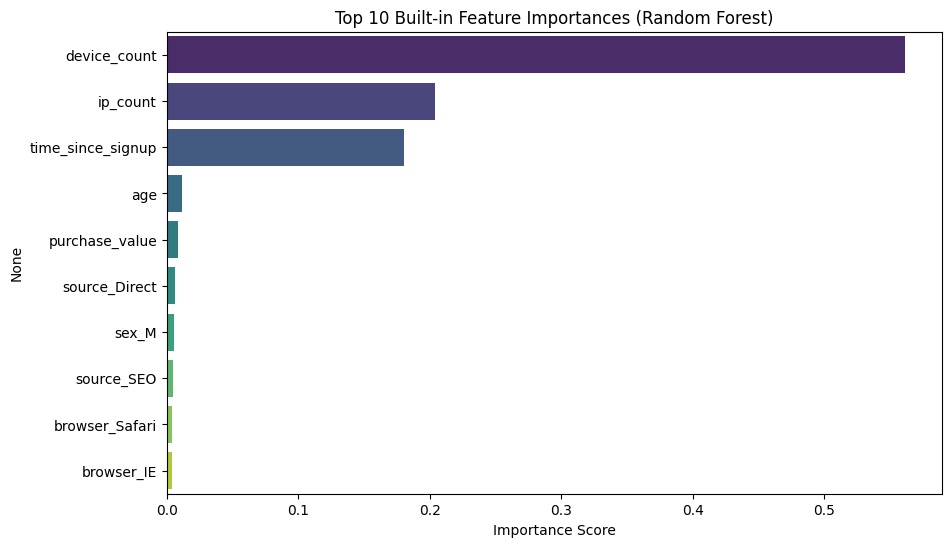

In [4]:
feat_imp = plot_builtin_importance(best_rf, X_test.columns)


Generating SHAP Summary Plots...


<Figure size 640x480 with 0 Axes>

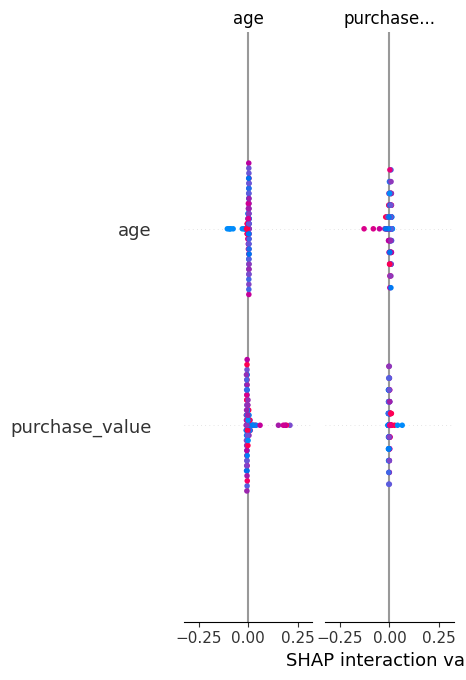

<Figure size 640x480 with 0 Axes>

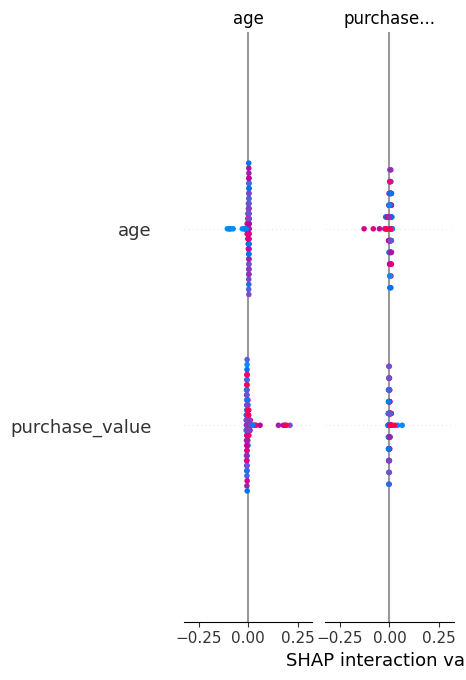

In [5]:
explainer, shap_values, X_sample = perform_shap_analysis(best_rf, X_test)

In [6]:
y_pred_sample = best_rf.predict(X_sample)
y_true_sample = y_test[X_sample.index]

In [ ]:
def perform_shap_analysis(model, X_test):
    """Generates SHAP values and robustly handles matrix shape."""
    # 1. Sample the data for performance
    X_sample = X_test.sample(min(100, len(X_test)), random_state=42)
    
    # 2. Initialize TreeExplainer
    explainer = shap.TreeExplainer(model)
    
    # 3. Calculate SHAP values
    shap_values = explainer.shap_values(X_sample)

    # Diagnostic prints
    print(f"Type of shap_values: {type(shap_values)}")
    if isinstance(shap_values, list):
        print(f"Length of shap_values list: {len(shap_values)}")
        print(f"Shape of first element: {shap_values[0].shape}")
        if len(shap_values) > 1:
            print(f"Shape of second element: {shap_values[1].shape}")
    else:
        print(f"Shape of shap_values: {shap_values.shape}")
    
    print(f"Type of expected_value: {type(explainer.expected_value)}")
    print(f"Expected value: {explainer.expected_value}")

    # Rest of your function...


Explaining True Positive (Fraud Caught) (Sample Index: 2)


ValueError: Unexpected SHAP format for TreeExplainer